In [1]:
# ============================================================
# RT-DETR + Roboflow YOLO11 전체 코드
# Roboflow project: elecourse-atjrg / merge_0626_3 / version 13
# ============================================================

# 1. 설치
!pip install -q roboflow ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 109.8 MB/s eta 0:00:00


In [2]:
# ============================================================
# 2. Roboflow YOLO11 데이터셋 다운로드
# ============================================================

from roboflow import Roboflow

rf = Roboflow(api_key="byjMEhXUKbKas3eLE2V9")
project = rf.workspace("elecourse-atjrg").project("merge_0626_3")
version = project.version(13)

# RT-DETR용: Ultralytics에서 읽을 수 있는 YOLO 형식
dataset = version.download("yolov11")

DATASET_ROOT = dataset.location
print("DATASET_ROOT:", DATASET_ROOT)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to merge_0626_3-13 in yolov11:: 100%|██████████| 6439/6439 [00:01<00:00, 3252.58it/s]

DATASET_ROOT: /content/merge_0626_3-13


In [3]:
# ============================================================
# 3. data.yaml 확인 및 경로 보정
# ============================================================

import os
import glob
import yaml
from pathlib import Path

yaml_candidates = glob.glob(os.path.join(DATASET_ROOT, "data.yaml"))

if len(yaml_candidates) == 0:
    yaml_candidates = glob.glob(os.path.join(DATASET_ROOT, "**", "data.yaml"), recursive=True)

if len(yaml_candidates) == 0:
    raise FileNotFoundError("data.yaml을 찾을 수 없습니다.")

DATA_YAML = yaml_candidates[0]
print("원본 data.yaml:", DATA_YAML)

with open(DATA_YAML, "r") as f:
    data = yaml.safe_load(f)

print("원본 yaml 내용:")
print(data)

# Roboflow yaml 경로가 상대경로일 때 Colab에서 꼬이는 경우가 있어서 절대경로 yaml 새로 생성
root = Path(DATASET_ROOT)

fixed_data = data.copy()

# train / val / test 경로를 실제 폴더 기준으로 강제 지정
fixed_data["path"] = str(root)
fixed_data["train"] = "train/images"

if (root / "valid" / "images").exists():
    fixed_data["val"] = "valid/images"
elif (root / "val" / "images").exists():
    fixed_data["val"] = "val/images"
elif (root / "test" / "images").exists():
    fixed_data["val"] = "test/images"
else:
    raise FileNotFoundError("valid/val/test images 폴더를 찾을 수 없습니다.")

if (root / "test" / "images").exists():
    fixed_data["test"] = "test/images"

FIXED_DATA_YAML = "/content/rtdetr_data_v13.yaml"

with open(FIXED_DATA_YAML, "w") as f:
    yaml.safe_dump(fixed_data, f, sort_keys=False, allow_unicode=True)

print("\n수정된 yaml 저장:", FIXED_DATA_YAML)

with open(FIXED_DATA_YAML, "r") as f:
    print(f.read())

원본 data.yaml: /content/merge_0626_3-13/data.yaml
원본 yaml 내용:
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 7, 'names': ['GPU', 'RAM', 'RAM_slot', 'eraser', 'hand', 'monitor', 'power_button_LED'], 'roboflow': {'workspace': 'elecourse-atjrg', 'project': 'merge_0626_3', 'version': 13, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/elecourse-atjrg/merge_0626_3/dataset/13'}}

수정된 yaml 저장: /content/rtdetr_data_v13.yaml
train: train/images
val: valid/images
test: test/images
nc: 7
names:
- GPU
- RAM
- RAM_slot
- eraser
- hand
- monitor
- power_button_LED
roboflow:
  workspace: elecourse-atjrg
  project: merge_0626_3
  version: 13
  license: CC BY 4.0
  url: https://universe.roboflow.com/elecourse-atjrg/merge_0626_3/dataset/13
path: /content/merge_0626_3-13



In [4]:
# ============================================================
# 4. RT-DETR 모델 학습
# ============================================================

from ultralytics import RTDETR
import torch

print("CUDA 사용 가능:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# RT-DETR pretrained 모델
# rtdetr-l.pt: 정확도/속도 균형
# rtdetr-x.pt: 더 크고 무거움
model = RTDETR("rtdetr-l.pt")

# T4에서 메모리 부족하면 batch=2 또는 batch=1로 낮추기
results = model.train(
    data=FIXED_DATA_YAML,
    epochs=50,
    imgsz=640,
    batch=4,
    device=0,
    workers=2,
    project="/content/rtdetr_runs",
    name="rtdetr_l_roboflow_v13",
    patience=10,
    optimizer="auto"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA 사용 가능: True
GPU: Tesla T4
Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rtdetr_data_v13.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freez

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


       1/50      3.62G     0.6612      2.806     0.3874         19        640: 100% ━━━━━━━━━━━━ 739/739 2.4it/s 5:13
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 2.1it/s 8.4s
                   all        137        447      0.671      0.694      0.692      0.442

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/50      3.82G     0.5877     0.6925     0.2598         22        640: 0% ──────────── 0/739  0.5s

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


       2/50      3.82G     0.5107     0.7091      0.271         11        640: 100% ━━━━━━━━━━━━ 739/739 2.5it/s 4:52
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 5.5it/s 3.3s
                   all        137        447      0.731      0.756      0.792      0.497

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/50      3.82G     0.5325     0.7618     0.2484         12        640: 0% ──────────── 0/739  0.4s

...

      41/50      3.82G     0.2348      0.334      0.126         10        640: 100% ━━━━━━━━━━━━ 739/739 2.5it/s 4:55
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 5.8it/s 3.1s
                   all        137        447      0.831      0.862      0.848      0.602

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      42/50      3.82G     0.3031     0.4155     0.1569         32        640: 0% ──────────── 0/739  0.4s

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


      42/50      3.82G     0.2323     0.3285      0.125          3        640: 100% ━━━━━━━━━━━━ 739/739 2.5it/s 4:53
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 5.9it/s 3.1s
                   all        137        447      0.823      0.845      0.852      0.599

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      43/50      3.82G     0.2292     0.4189    0.07913         15        640: 0% ──────────── 0/739  0.4s

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


      43/50      3.82G     0.2231      0.319     0.1144          9        640: 100% ━━━━━━━━━━━━ 739/739 2.5it/s 4:53
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 5.8it/s 3.1s
                   all        137        447      0.835       0.85      0.845       0.59
EarlyStopping: Training stopped early as no improvement observed in last 10 epochs. Best results observed at epoch 33, best model saved as best.pt.
To update EarlyStopping(patience=10) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

43 epochs completed in 3.750 hours.
Optimizer stripped from /content/rtdetr_runs/rtdetr_l_roboflow_v13/weights/last.pt, 66.2MB
Optimizer stripped from /content/rtdetr_runs/rtdetr_l_roboflow_v13/weights/best.pt, 66.2MB

Validating /content/rtdetr_runs/rtdetr_l_roboflow_v13/weights/best.pt...
Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l su

In [5]:
# ============================================================
# 5. RT-DETR 검증
# ============================================================

metrics = model.val(
    data=FIXED_DATA_YAML,
    imgsz=640,
    batch=4,
    device=0,
    split="val"
)

print(metrics)

Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,998,125 parameters, 0 gradients, 103.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1276.1±398.9 MB/s, size: 41.5 KB)
val: Scanning /content/merge_0626_3-13/valid/labels.cache... 137 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 137/137 44.2Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 10, len(boxes) = 447. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 5.5it/s 6.4s
                   all        137        447      0.851      0.853      0.874       0.62
                   GPU         18         23      0.738      0.733      0.743       0.43
                   RAM         52    

In [6]:
# ============================================================
# 6. best.pt 위치 확인
# ============================================================

import glob

best_candidates = glob.glob("/content/rtdetr_runs/rtdetr_l_roboflow_v13/weights/best.pt")

if len(best_candidates) == 0:
    best_candidates = glob.glob("/content/rtdetr_runs/**/weights/best.pt", recursive=True)

BEST_PT = best_candidates[0]
print("BEST_PT:", BEST_PT)

BEST_PT: /content/rtdetr_runs/rtdetr_l_roboflow_v13/weights/best.pt


In [7]:
# ============================================================
# 7. best.pt 로드 후 최종 평가
# ============================================================

best_model = RTDETR(BEST_PT)

final_metrics = best_model.val(
    data=FIXED_DATA_YAML,
    imgsz=640,
    batch=4,
    device=0,
    split="val"
)

print("최종 metrics:")
print(final_metrics)

# Ultralytics metrics 값 꺼내기
map_5095 = final_metrics.box.map
map_50 = final_metrics.box.map50
map_75 = final_metrics.box.map75

print("mAP 50-95:", map_5095)
print("mAP 50:", map_50)
print("mAP 75:", map_75)

Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,998,125 parameters, 0 gradients, 103.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1220.7±538.1 MB/s, size: 45.2 KB)
val: Scanning /content/merge_0626_3-13/valid/labels.cache... 137 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 137/137 44.2Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 10, len(boxes) = 447. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 5.2it/s 6.7s
                   all        137        447      0.851      0.853      0.874       0.62
                   GPU         18         23      0.738      0.733      0.743       0.43
                   RAM         52    

테스트 이미지: /content/merge_0626_3-13/valid/images/instalacao-hd-2_mp4-0040_jpg.rf.c0d534b984855ca69ad97e164daca696.jpg

image 1/1 /content/merge_0626_3-13/valid/images/instalacao-hd-2_mp4-0040_jpg.rf.c0d534b984855ca69ad97e164daca696.jpg: 640x640 1 RAM, 2 hands, 69.6ms
Speed: 2.1ms preprocess, 69.6ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/rtdetr_predictions/predict


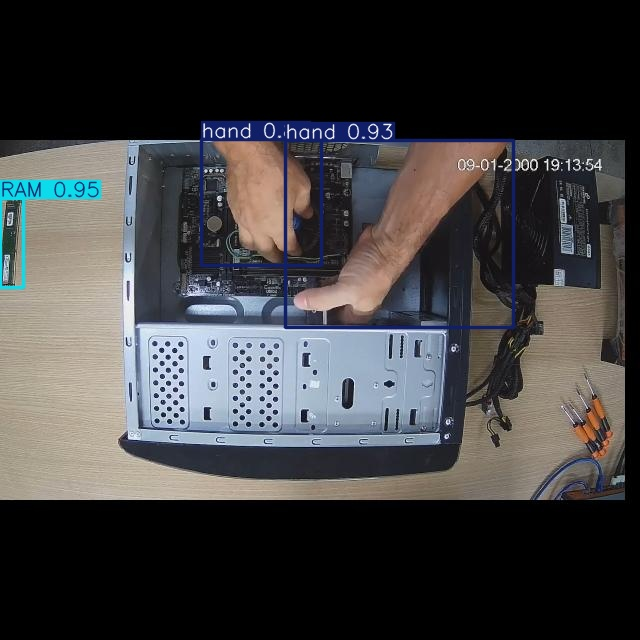

In [8]:
# ============================================================
# 8. RT-DETR 예측 결과 시각화
# ============================================================

import os
import glob
from IPython.display import Image, display

# valid 이미지 하나 가져오기
valid_images = glob.glob(os.path.join(DATASET_ROOT, "valid", "images", "*"))

if len(valid_images) == 0:
    valid_images = glob.glob(os.path.join(DATASET_ROOT, "val", "images", "*"))

if len(valid_images) == 0:
    valid_images = glob.glob(os.path.join(DATASET_ROOT, "test", "images", "*"))

if len(valid_images) == 0:
    raise FileNotFoundError("예측 테스트용 이미지를 찾을 수 없습니다.")

test_image = valid_images[0]
print("테스트 이미지:", test_image)

pred_results = best_model.predict(
    source=test_image,
    conf=0.25,
    imgsz=640,
    save=True,
    project="/content/rtdetr_predictions",
    name="predict",
    device=0
)

pred_images = glob.glob("/content/rtdetr_predictions/predict/*")

if len(pred_images) > 0:
    display(Image(filename=pred_images[0]))
else:
    print("예측 이미지 저장 위치 확인 필요: /content/rtdetr_predictions/predict")

In [9]:
# ============================================================
# 9. RT-DETR 추론 속도 측정
# ============================================================

import time
import torch
from PIL import Image as PILImage

def benchmark_ultralytics_model(model, image_paths, num_images=50):
    n = min(num_images, len(image_paths))
    sample_paths = image_paths[:n]

    # warm-up
    for p in sample_paths[:5]:
        _ = model.predict(
            source=p,
            imgsz=640,
            conf=0.25,
            device=0,
            verbose=False
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start = time.time()

    for p in sample_paths:
        _ = model.predict(
            source=p,
            imgsz=640,
            conf=0.25,
            device=0,
            verbose=False
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    elapsed = time.time() - start
    fps = n / elapsed
    ms_per_image = (elapsed / n) * 1000

    print(f"측정 이미지 수: {n}")
    print(f"총 시간: {elapsed:.3f}s")
    print(f"평균 ms/image: {ms_per_image:.2f} ms")
    print(f"FPS: {fps:.2f}")

    return fps, ms_per_image


valid_images = glob.glob(os.path.join(DATASET_ROOT, "valid", "images", "*"))
if len(valid_images) == 0:
    valid_images = glob.glob(os.path.join(DATASET_ROOT, "val", "images", "*"))
if len(valid_images) == 0:
    valid_images = glob.glob(os.path.join(DATASET_ROOT, "test", "images", "*"))

fps, ms_per_image = benchmark_ultralytics_model(best_model, valid_images, num_images=50)

측정 이미지 수: 50
총 시간: 3.257s
평균 ms/image: 65.15 ms
FPS: 15.35


In [10]:
# ============================================================
# 10. RT-DETR 파라미터 수 확인
# ============================================================

total_params = sum(p.numel() for p in best_model.model.parameters())
trainable_params = sum(p.numel() for p in best_model.model.parameters() if p.requires_grad)

print(f"전체 파라미터 수: {total_params:,}")
print(f"학습 가능 파라미터 수: {trainable_params:,}")

전체 파라미터 수: 31,998,125
학습 가능 파라미터 수: 0


In [11]:
# ============================================================
# 11. 발표용 결과 요약 출력
# ============================================================

print("========== RT-DETR 발표용 요약 ==========")
print("Model: RT-DETR-L")
print("Dataset: Roboflow merge_0626_3 version 13 / YOLO11 export")
print(f"mAP 50-95: {map_5095:.4f}")
print(f"mAP 50:    {map_50:.4f}")
print(f"mAP 75:    {map_75:.4f}")
print(f"FPS:        {fps:.2f}")
print(f"ms/image:   {ms_per_image:.2f}")
print(f"Params:     {total_params:,}")
print("best.pt:", BEST_PT)
print("========================================")

========== RT-DETR 발표용 요약 ==========
Model: RT-DETR-L
Dataset: Roboflow merge_0626_3 version 13 / YOLO11 export
mAP 50-95: 0.6201
mAP 50:    0.8737
mAP 75:    0.6826
FPS:        15.35
ms/image:   65.15
Params:     31,998,125
best.pt: /content/rtdetr_runs/rtdetr_l_roboflow_v13/weights/best.pt
